In [1]:
# =========================================================
# BRAIN TUMOR SEGMENTATION USING MONAI 3D U-NET
# BraTS Dataset
# Memory Efficient Version
# =========================================================

!pip install -q monai nibabel

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 39.6 MB/s eta 0:00:00a 0:00:01


In [2]:
import os
import glob
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
import torch
import tarfile
import random
import shutil
import nibabel as nib

from torch.utils.data import Dataset, DataLoader

from monai.networks.nets import UNet
from monai.losses import DiceLoss

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.
2026-05-21 11:03:10.346408: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779361390.540316      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779361390.596071      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779361391.037692      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779361391.037733      57 computation_placer.cc:1

In [3]:
# ============================================
# TASK:
# 1. Extract BraTS2021_Training_Data.tar
# 2. Randomly select ONLY 300 patients
# 3. Remove remaining patients
# 4. Save final dataset
# ============================================


# ============================================
# PATHS
# ============================================

TAR_PATH = "/kaggle/input/datasets/dschettler8845/brats-2021-task1/BraTS2021_Training_Data.tar"

EXTRACT_PATH = "/kaggle/working/brats_extracted"

FINAL_DATASET_PATH = "/kaggle/working/BraTS2021_300Patients"

SEED = 42

# ============================================
# CREATE FOLDERS
# ============================================

os.makedirs(EXTRACT_PATH, exist_ok=True)

os.makedirs(FINAL_DATASET_PATH, exist_ok=True)

# ============================================
# EXTRACT TAR FILE
# ============================================

print("Extracting dataset...")

with tarfile.open(TAR_PATH, "r") as tar:
    tar.extractall(path=EXTRACT_PATH)

print("Extraction Completed")

Extracting dataset...


/tmp/ipykernel_57/2944466489.py:37: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=EXTRACT_PATH)


Extraction Completed


In [4]:
# ============================================
# FIND MAIN DATASET FOLDER
# ============================================

dataset_folder = EXTRACT_PATH
    
# ============================================
# GET ALL PATIENTS
# ============================================

all_patients = sorted([
    p for p in os.listdir(dataset_folder)
    if os.path.isdir(os.path.join(dataset_folder, p))
])

print(f"Total Patients Found: {len(all_patients)}")

# ============================================
# RANDOMLY SELECT 300 PATIENTS
# ============================================

random.seed(SEED)

selected_patients = random.sample(
    all_patients,
    300
)

print(f"Selected Patients: {len(selected_patients)}")

# ============================================
# COPY ONLY 300 PATIENTS
# ============================================

# ============================================
# COPY ONLY 300 PATIENTS
# ============================================

print("Copying selected patients...")

for patient in selected_patients:

    src = os.path.join(dataset_folder, patient)

    dst = os.path.join(FINAL_DATASET_PATH, patient)

    shutil.copytree(
        src,
        dst,
        dirs_exist_ok=True
    )

print("Finished Copying")

# ============================================
# VERIFY FINAL DATASET
# ============================================

final_count = len(os.listdir(FINAL_DATASET_PATH))

print(f"Final Dataset Patients: {final_count}")


Total Patients Found: 1251
Selected Patients: 300
Copying selected patients...
Finished Copying
Final Dataset Patients: 300


In [5]:
# ============================================
# OPTIONAL:
# DELETE EXTRACTED FULL DATASET
# ============================================

shutil.rmtree(EXTRACT_PATH)

print("Removed Remaining Patients")

# ============================================
# FINAL DATASET LOCATION
# ============================================

print(f"Final Dataset Path: {FINAL_DATASET_PATH}")

Removed Remaining Patients
Final Dataset Path: /kaggle/working/BraTS2021_300Patients


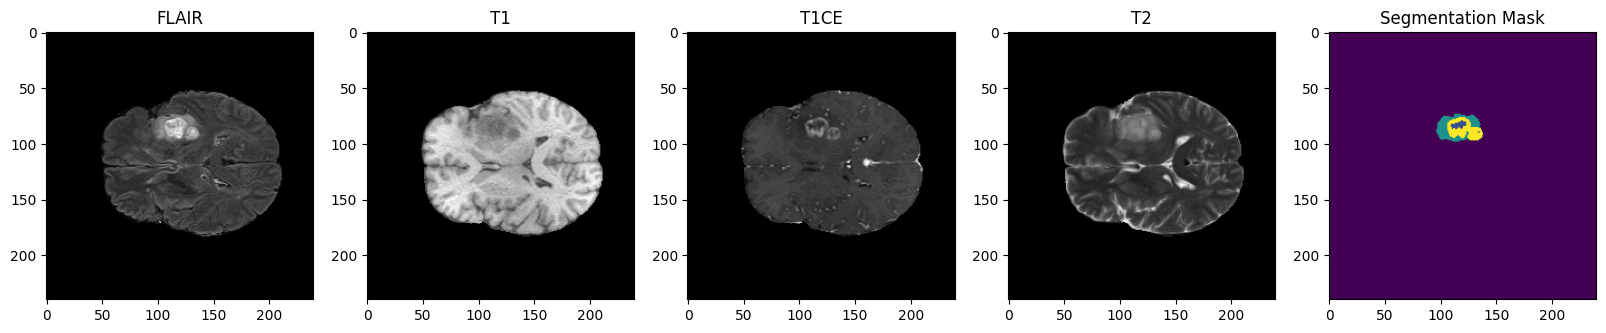

In [6]:
# ============================================
# VISUALIZE MRI MODALITIES
# ============================================

DATASET_PATH = "/kaggle/working/BraTS2021_300Patients"

patient = os.listdir(DATASET_PATH)[0]

patient_path = os.path.join(DATASET_PATH, patient)

flair = nib.load(glob.glob(patient_path + "/*flair.nii.gz")[0]).get_fdata()
t1 = nib.load(glob.glob(patient_path + "/*t1.nii.gz")[0]).get_fdata()
t1ce = nib.load(glob.glob(patient_path + "/*t1ce.nii.gz")[0]).get_fdata()
t2 = nib.load(glob.glob(patient_path + "/*t2.nii.gz")[0]).get_fdata()
seg = nib.load(glob.glob(patient_path + "/*seg.nii.gz")[0]).get_fdata()

slice_id = 75

fig, ax = plt.subplots(1,5, figsize=(20,5))

ax[0].imshow(flair[:,:,slice_id], cmap='gray')
ax[0].set_title("FLAIR")

ax[1].imshow(t1[:,:,slice_id], cmap='gray')
ax[1].set_title("T1")

ax[2].imshow(t1ce[:,:,slice_id], cmap='gray')
ax[2].set_title("T1CE")

ax[3].imshow(t2[:,:,slice_id], cmap='gray')
ax[3].set_title("T2")

ax[4].imshow(seg[:,:,slice_id])
ax[4].set_title("Segmentation Mask")

plt.show()

In [7]:
# =========================================================
# DEVICE
# =========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


Device: cuda


In [8]:
import cv2

IMG_SIZE = 128

def normalize(volume):
    
    volume = (volume - np.min(volume)) / (np.max(volume) - np.min(volume))
    
    return volume


def resize_slice(slice_img):
    
    return cv2.resize(slice_img, (IMG_SIZE, IMG_SIZE))


def load_patient(patient_path):
    
    flair = nib.load(glob.glob(patient_path + "/*flair.nii.gz")[0]).get_fdata()
    t1 = nib.load(glob.glob(patient_path + "/*t1.nii.gz")[0]).get_fdata()
    t1ce = nib.load(glob.glob(patient_path + "/*t1ce.nii.gz")[0]).get_fdata()
    t2 = nib.load(glob.glob(patient_path + "/*t2.nii.gz")[0]).get_fdata()
    
    seg = nib.load(glob.glob(patient_path + "/*seg.nii.gz")[0]).get_fdata()
    
    flair = normalize(flair)
    t1 = normalize(t1)
    t1ce = normalize(t1ce)
    t2 = normalize(t2)
    
    return flair, t1, t1ce, t2, seg

In [9]:
def one_hot_mask(mask):
    
    n_classes = 4
    
    one_hot = np.zeros(mask.shape + (n_classes,))
    
    for i, label in enumerate([0,1,2,4]):
        one_hot[:,:,:,i] = (mask == label)
        
    return one_hot

In [10]:
from monai.transforms import (
    Compose,
    RandFlip,
    RandRotate90,
    RandZoom,
    RandGaussianNoise,
    RandAdjustContrast
)

train_transforms = Compose([

    RandFlip(
        prob=0.5,
        spatial_axis=0
    ),

    RandFlip(
        prob=0.5,
        spatial_axis=1
    ),

    RandRotate90(
        prob=0.5,
        max_k=3
    ),

    RandZoom(
        min_zoom=0.9,
        max_zoom=1.1,
        prob=0.3
    ),

    RandGaussianNoise(
        prob=0.2,
        mean=0.0,
        std=0.01
    ),

    RandAdjustContrast(
        prob=0.3,
        gamma=(0.7, 1.5)
    )
])

In [11]:
# =========================================================
# EVICE
# =========================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [12]:
# =========================================================
# DATASET PATH
# =========================================================

DATASET_PATH = FINAL_DATASET_PATH

In [13]:
# =========================================================
# DATASET CLASS
# =========================================================

class BraTSDataset(Dataset):

    def __init__(self, dataset_path):

        self.dataset_path = dataset_path

        self.patients = sorted([
            p for p in os.listdir(dataset_path)
            if os.path.isdir(os.path.join(dataset_path, p))
        ])

    def __len__(self):
        return len(self.patients)

    def __getitem__(self, idx):

        patient = self.patients[idx]

        patient_path = os.path.join(self.dataset_path, patient)

        files = os.listdir(patient_path)

        flair = [f for f in files if "flair" in f][0]
        t1    = [f for f in files if "t1.nii" in f and "ce" not in f][0]
        t1ce  = [f for f in files if "t1ce" in f][0]
        t2    = [f for f in files if "t2" in f and "t1" not in f][0]
        seg   = [f for f in files if "seg" in f][0]

        flair = nib.load(os.path.join(patient_path, flair)).get_fdata()
        t1    = nib.load(os.path.join(patient_path, t1)).get_fdata()
        t1ce  = nib.load(os.path.join(patient_path, t1ce)).get_fdata()
        t2    = nib.load(os.path.join(patient_path, t2)).get_fdata()
        seg   = nib.load(os.path.join(patient_path, seg)).get_fdata()

        # =====================================================
        # STACK MODALITIES
        # Shape:
        # [4, 240, 240, 155]
        # =====================================================

        image = np.stack([flair, t1, t1ce, t2], axis=0)

        # =====================================================
        # FIX U-NET DIMENSION ISSUE
        # 155 -> 144
        # =====================================================

        image = image[:, :, :, :144]
        seg = seg[:, :, :144]

        # =====================================================
        # NORMALIZATION
        # =====================================================

        image = image.astype(np.float32)

        image = (image - image.mean()) / (image.std() + 1e-8)

        # =====================================================
        # LABEL FIX
        # BraTS uses label 4
        # Convert:
        # 4 -> 3
        # =====================================================

        seg[seg == 4] = 3

        seg = seg.astype(np.uint8)

        # =====================================================
        # TO TENSOR
        # =====================================================

        image = torch.tensor(image, dtype=torch.float32)

        seg = torch.tensor(seg, dtype=torch.long)

        return image, seg

In [14]:
# =========================================================
# CREATE DATASET
# =========================================================

dataset = BraTSDataset(DATASET_PATH)

print("Total Patients:", len(dataset))

Total Patients: 300


In [15]:
# =========================================================
# DATALOADER
# =========================================================

train_loader = DataLoader(
    dataset,
    batch_size=1,
    shuffle=True,
    num_workers=2
)


In [16]:
# =========================================================
# TEST DATA
# =========================================================

images, masks = next(iter(train_loader))

print("Images Shape:", images.shape)
print("Masks Shape:", masks.shape)

# Expected:
# Images Shape: [1, 4, 240, 240, 144]
# Masks Shape: [1, 240, 240, 144]

Images Shape: torch.Size([1, 4, 240, 240, 144])
Masks Shape: torch.Size([1, 240, 240, 144])


In [17]:
# =========================================================
# CREATE 3D U-NET MODEL
# =========================================================

model = UNet(

    spatial_dims=3,

    in_channels=4,

    out_channels=4,

    channels=(16, 32, 64, 128),

    strides=(2, 2, 2),

    num_res_units=2

).to(device)

print(model)


UNet(
  (model): Sequential(
    (0): ResidualUnit(
      (conv): Sequential(
        (unit0): Convolution(
          (conv): Conv3d(4, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
        (unit1): Convolution(
          (conv): Conv3d(16, 16, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
          (adn): ADN(
            (N): InstanceNorm3d(16, eps=1e-05, momentum=0.1, affine=False, track_running_stats=False)
            (D): Dropout(p=0.0, inplace=False)
            (A): PReLU(num_parameters=1)
          )
        )
      )
      (residual): Conv3d(4, 16, kernel_size=(3, 3, 3), stride=(2, 2, 2), padding=(1, 1, 1))
    )
    (1): SkipConnection(
      (submodule): Sequential(
        (0): ResidualUnit(
          (conv): Se

In [18]:
# =========================================================
# 10. LOSS FUNCTION
# =========================================================

loss_function = DiceLoss(
    to_onehot_y=True,
    softmax=True
)

# =========================================================
# 11. OPTIMIZER
# =========================================================

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)


In [19]:
# =========================================================
# 12. TRAINING LOOP
# =========================================================

EPOCHS = 50

for epoch in range(EPOCHS):

    model.train()

    epoch_loss = 0

    for images, masks in train_loader:

        images = images.to(device)

        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = loss_function(outputs, masks.unsqueeze(1))

        loss.backward()

        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {avg_loss:.4f}")

Epoch 1/50 | Loss: 0.8212
Epoch 2/50 | Loss: 0.7257
Epoch 3/50 | Loss: 0.6221
Epoch 4/50 | Loss: 0.5588
Epoch 5/50 | Loss: 0.5346
Epoch 6/50 | Loss: 0.5189
Epoch 7/50 | Loss: 0.5068
Epoch 8/50 | Loss: 0.4362
Epoch 9/50 | Loss: 0.3487
Epoch 10/50 | Loss: 0.3261
Epoch 11/50 | Loss: 0.3072
Epoch 12/50 | Loss: 0.2952
Epoch 13/50 | Loss: 0.2951
Epoch 14/50 | Loss: 0.2794
Epoch 15/50 | Loss: 0.2771
Epoch 16/50 | Loss: 0.2696
Epoch 17/50 | Loss: 0.2674
Epoch 18/50 | Loss: 0.2641
Epoch 19/50 | Loss: 0.2567
Epoch 20/50 | Loss: 0.2554
Epoch 21/50 | Loss: 0.2587
Epoch 22/50 | Loss: 0.2568
Epoch 23/50 | Loss: 0.2491
Epoch 24/50 | Loss: 0.2443
Epoch 25/50 | Loss: 0.2512
Epoch 26/50 | Loss: 0.2402
Epoch 27/50 | Loss: 0.2356
Epoch 28/50 | Loss: 0.2293
Epoch 29/50 | Loss: 0.2306
Epoch 30/50 | Loss: 0.2289
Epoch 31/50 | Loss: 0.2237
Epoch 32/50 | Loss: 0.2222
Epoch 33/50 | Loss: 0.2195
Epoch 34/50 | Loss: 0.2249
Epoch 35/50 | Loss: 0.2199
Epoch 36/50 | Loss: 0.2219
Epoch 37/50 | Loss: 0.2161
Epoch 38/5

In [20]:
# =========================================================
# 13. SAVE MODEL
# =========================================================

torch.save(model.state_dict(), "brain_tumor_unet.pth")

print("Model Saved")


Model Saved


In [21]:
# =========================================================
# 14. INFERENCE TEST
# =========================================================

model.eval()

with torch.no_grad():

    sample_image, sample_mask = dataset[0]

    sample_image = sample_image.unsqueeze(0).to(device)

    prediction = model(sample_image)

    prediction = torch.argmax(prediction, dim=1)

print("Prediction Shape:", prediction.shape)



Prediction Shape: torch.Size([1, 240, 240, 144])


In [22]:
from monai.metrics import DiceMetric

dice_metric = DiceMetric(
    include_background=False,
    reduction="mean"
)

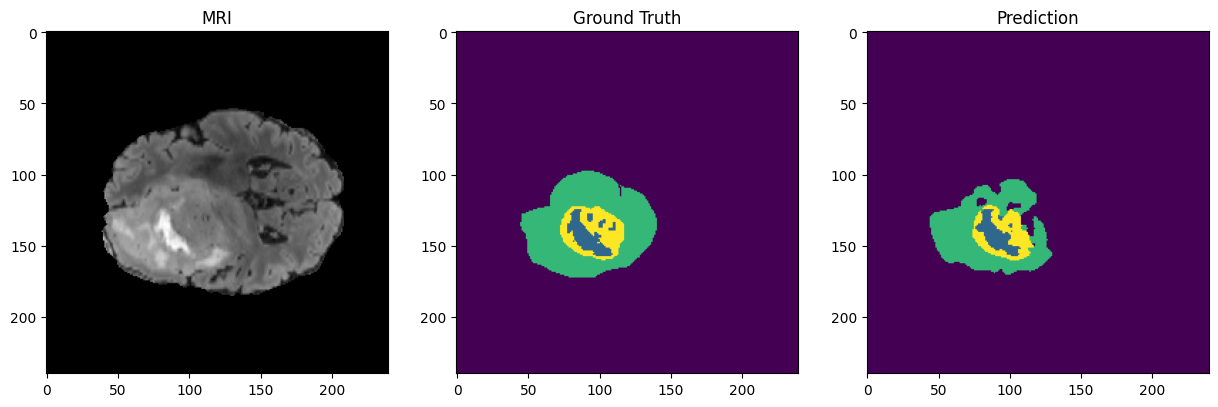

In [23]:
model.eval()

with torch.no_grad():
    
    sample_image, sample_mask = dataset[0]
    
    prediction = model(sample_image.unsqueeze(0).to(device))
    
    prediction = torch.argmax(prediction, dim=1).cpu().numpy()[0]

slice_id = 75

fig, ax = plt.subplots(1,3, figsize=(15,5))

ax[0].imshow(sample_image[0,:,:,slice_id], cmap='gray')
ax[0].set_title("MRI")

ax[1].imshow(sample_mask[:,:,slice_id])
ax[1].set_title("Ground Truth")

ax[2].imshow(prediction[:,:,slice_id])
ax[2].set_title("Prediction")

plt.show()